<a href="https://colab.research.google.com/github/ptsouth97/WIYN-spectroscopy-pipeline/blob/main/Spectral_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Open file

In [39]:
from astropy.io import fits

filename = "kwb_080517_043236_ori.fits.fz"

with fits.open(filename) as hdul:
    hdul.info()

    # Primary header
    print(hdul[0].header)

    # Data from first extension (common for compressed FITS)
    data = hdul[1].data
    header = hdul[1].header

print(data.shape)

Filename: kwb_080517_043236_ori.fits.fz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   ()      
  1  COMPRESSED_IMAGE    1 CompImageHDU    214   (1352, 2000)   int32 (rescales to uint32)   
SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                   16 / number of bits per data pixel                  NAXIS   =                    0 / number of data axes                            EXTEND  =                    T / FITS dataset may contain extensions            COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H CHECKSUM= 'nbD3naC2naC2naC2'   / HDU checksum updated 2020-06-11T09:58:33       DATASUM = '0       '           / data unit checksum updated 2020-06-11T09:58:33 END                                                                                                              

#Inspect file shape

In [40]:
with fits.open(filename) as hdul:
    for i, hdu in enumerate(hdul):

        shape = None
        if hdu.data is not None:
            shape = hdu.data.shape

        print(
            f"HDU {i:2d}",
            f"name={hdu.name}",
            f"shape={shape}"
        )

HDU  0 name=PRIMARY shape=None
HDU  1 name=COMPRESSED_IMAGE shape=(2000, 1352)


#Target Name

In [41]:
from astropy.io import fits

with fits.open(filename) as hdul:
    header = hdul[1].header

print(header["OBJECT"])
print(header["WAVELEN"])
print(header["GRATNAME"])

m67_b2_blue_may08


KeyError: "Keyword 'WAVELEN' not found."

#Inspect Target


*   Looking for
*   OBJECT   = stellar target
*   WAVELEN  = 6500-6600
*   IMAGETYP = object
`



In [42]:
from astropy.io import fits

with fits.open(filename) as hdul:
    header = hdul[1].header

print("OBJECT   =", header.get("OBJECT"))
print("WAVELEN  =", header.get("WAVELEN"))
print("GRATNAME =", header.get("GRATNAME"))
print("IMAGETYP =", header.get("IMAGETYP"))

OBJECT   = m67_b2_blue_may08
WAVELEN  = None
GRATNAME = 316@63.4
IMAGETYP = OBJECT


#Type of image

In [43]:
from astropy.io import fits

with fits.open(filename) as hdul:
    hdr = hdul[1].header

for key in [
    "OBJECT",
    "IMAGETYP",
    "OBSTYPE",
    "EXPTIME",
    "DATE-OBS",
    "GRATING",
    "FILTER",
    "LAMP",
    "RA",
    "DEC"
]:
    print(f"{key:10s} : {hdr.get(key)}")


OBJECT     : m67_b2_blue_may08
IMAGETYP   : OBJECT
OBSTYPE    : OBJECT
EXPTIME    : 1200.0
DATE-OBS   : 2008-05-17T04:11:22.0
GRATING    : None
FILTER     : None
LAMP       : None
RA         : +08:51:39.808
DEC        : +11:51:56.917


#Display the image

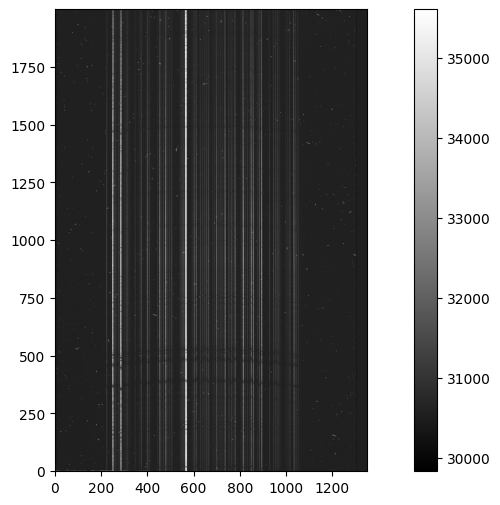

In [44]:
import matplotlib.pyplot as plt
from astropy.io import fits

with fits.open(filename) as hdul:
    image = hdul[1].data

plt.figure(figsize=(12,6))
plt.imshow(
    image,
    origin="lower",
    cmap="gray",
    vmin=image.mean()-image.std(),
    vmax=image.mean()+5*image.std()
)
plt.colorbar()
plt.show()

#Find the spectrograph setup

In [45]:
from astropy.io import fits

with fits.open(filename) as hdul:
    hdr = hdul[1].header

for key in sorted(hdr):
    if any(word in key.upper() for word in
           ["WAVE", "GRAT", "LAMB", "DISP", "CAM", "FOCUS", "FILTER"]):
        print(f"{key:20s} {hdr[key]}")

CAMANGLE             11.0
CAMFOCUS             -0.023
CAMNAME              Bench Spect (Red) Camera
CAMTEMP              152.0
FIBFOCUS             -0.162
FOCUS                -99990.0
GRATANGL             68.989
GRATNAME             316@63.4


#Find Fiber Positions

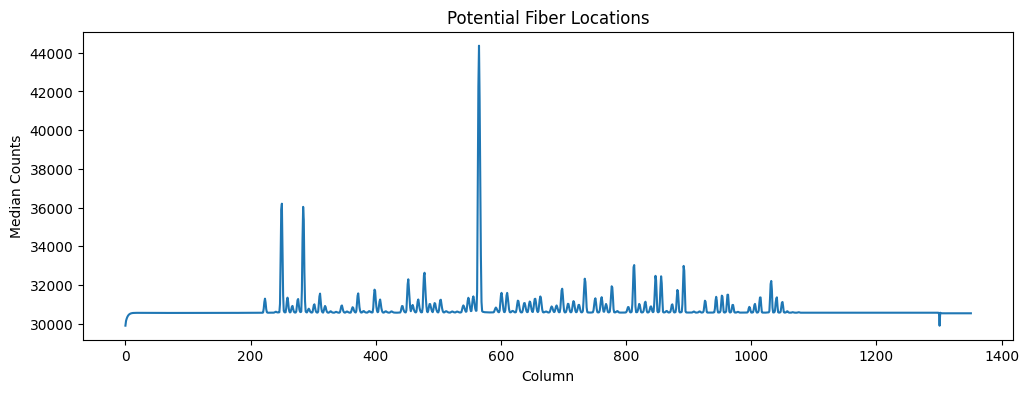

In [46]:
import numpy as np
import matplotlib.pyplot as plt

profile = np.median(image, axis=0)

plt.figure(figsize=(12,4))
plt.plot(profile)
plt.xlabel("Column")
plt.ylabel("Median Counts")
plt.title("Potential Fiber Locations")
plt.show()

#Extract one fiber spectrum


*   Automatically find the brightest fiber and extract it



Found 89 fibers


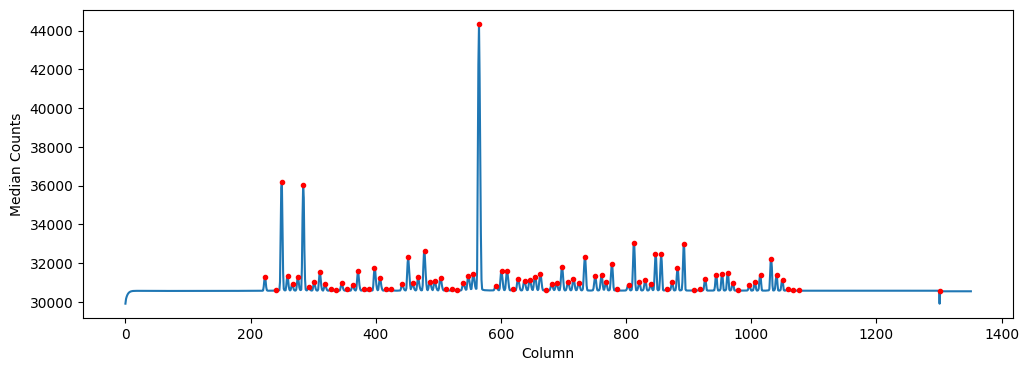

[223 240 250 259 267 276 284 293 302 311]


In [47]:
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

profile = np.median(image, axis=0)

peaks, _ = find_peaks(
    profile,
    prominence=20,
    distance=5
)

print(f"Found {len(peaks)} fibers")

plt.figure(figsize=(12,4))
plt.plot(profile)
plt.plot(peaks, profile[peaks], "r.")
plt.xlabel("Column")
plt.ylabel("Median Counts")
plt.show()

print(peaks[:10])

#Extract a spectrum from the brightest fiber

Brightest fiber: 565


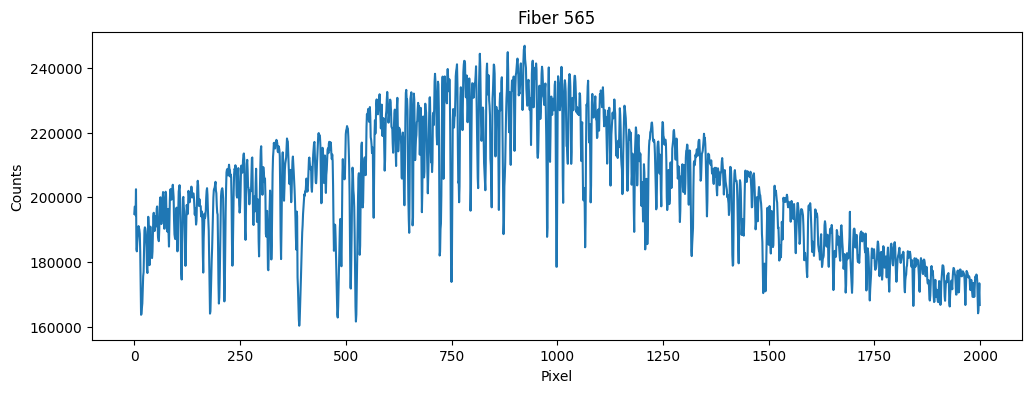

In [48]:
brightest_fiber = peaks[np.argmax(profile[peaks])]
print(f"Brightest fiber: {brightest_fiber}")

half_width = 2

spectrum = image[
    :,
    brightest_fiber-half_width:brightest_fiber+half_width+1
].sum(axis=1)

plt.figure(figsize=(12,4))
plt.plot(spectrum)
plt.xlabel("Pixel")
plt.ylabel("Counts")
plt.title(f"Fiber {brightest_fiber}")
plt.show()

#Normalize the spectrum

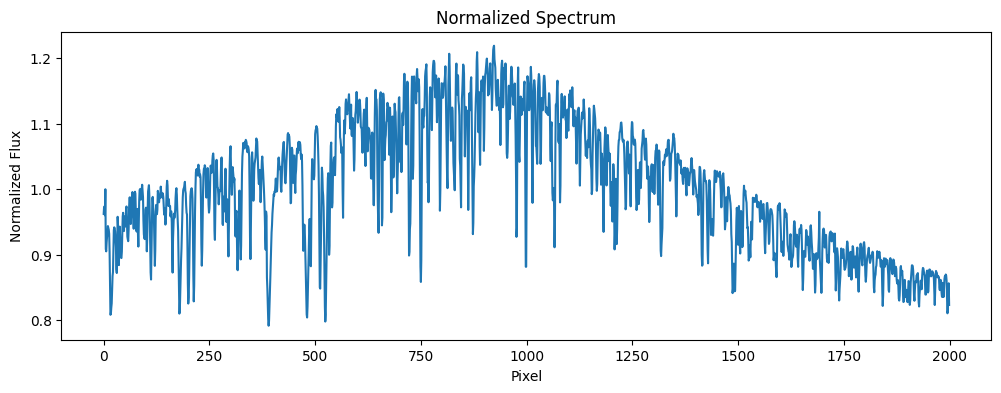

In [49]:
spectrum_norm = spectrum / np.median(spectrum)

plt.figure(figsize=(12,4))
plt.plot(spectrum_norm)
plt.xlabel("Pixel")
plt.ylabel("Normalized Flux")
plt.title("Normalized Spectrum")
plt.show()

#Identify the central fiber automatically

In [50]:
fiber_table = list(zip(peaks, profile[peaks]))

fiber_table_sorted = sorted(
    fiber_table,
    key=lambda x: x[1],
    reverse=True
)

for col, value in fiber_table_sorted[:10]:
    print(f"Column={col:3d}, Profile={value:.1f}")

Column=565, Profile=44358.0
Column=250, Profile=36203.5
Column=284, Profile=36039.5
Column=813, Profile=33034.0
Column=892, Profile=32991.5
Column=478, Profile=32638.0
Column=847, Profile=32479.0
Column=856, Profile=32455.0
Column=734, Profile=32331.0
Column=452, Profile=32300.0


#Print all spectra shape

In [51]:
all_spectra = []

half_width = 2

for fiber in peaks:
    spectrum = image[
        :,
        fiber-half_width:fiber+half_width+1
    ].sum(axis=1)

    all_spectra.append(spectrum)

all_spectra = np.array(all_spectra)

print(all_spectra.shape)

(89, 2000)
